In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

ruta = "netflix_titles.csv"
df = pd.read_csv(ruta)




Separar datos

In [42]:
df_movies = df[df['type'] == 'Movie'].copy()
df_shows = df[df['type'] == 'TV Show'].copy()


Preparar duracion en minutos

In [43]:
df_movies = df_movies.dropna(subset=['duration'])
df_movies = df_movies[df_movies['duration'].str.contains('min', na=False)]
df_movies['duration_minutes'] = df_movies['duration'].str.extract('(\d+)').astype(float)
df_shows = df_shows.dropna(subset=['duration'])
df_shows = df_shows[df_shows['duration'].str.contains('Season', na=False)]
df_shows['duration_seasons'] = df_shows['duration'].str.extract('(\d+)').astype(float)
df_movies['duration_value'] = df_movies['duration_minutes']
df_shows['duration_value'] = df_shows['duration_seasons'] * 300


<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
C:\Users\eulal\AppData\Local\Temp\ipykernel_8924\3482613981.py:3: SyntaxWarning: invalid escape sequence '\d'
  df_movies['duration_minutes'] = df_movies['duration'].str.extract('(\d+)').astype(float)
C:\Users\eulal\AppData\Local\Temp\ipykernel_8924\3482613981.py:6: SyntaxWarning: invalid escape sequence '\d'
  df_shows['duration_seasons'] = df_shows['duration'].str.extract('(\d+)').astype(float)


Combinar ambos datasets

In [44]:
df_clasificacion = pd.concat([df_movies, df_shows])

Tratamiento de datos 

In [45]:
df_clasificacion = df_clasificacion.dropna(subset=['release_year', 'duration_value'])
df_clasificacion['type'] = df_clasificacion['type'].map({'Movie': 0, 'TV Show': 1})


Division de datos

In [46]:
X = df_clasificacion[['release_year', 'duration_value']]
y = df_clasificacion['type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Entrenamiento del modelo KNN (k=5)

In [47]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

Evaluacion del modelo

In [48]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión del modelo: {accuracy * 100:.2f}%")

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

Precisión del modelo: 99.96%

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1839
           1       1.00      1.00      1.00       803

    accuracy                           1.00      2642
   macro avg       1.00      1.00      1.00      2642
weighted avg       1.00      1.00      1.00      2642



Matriz de Confusion

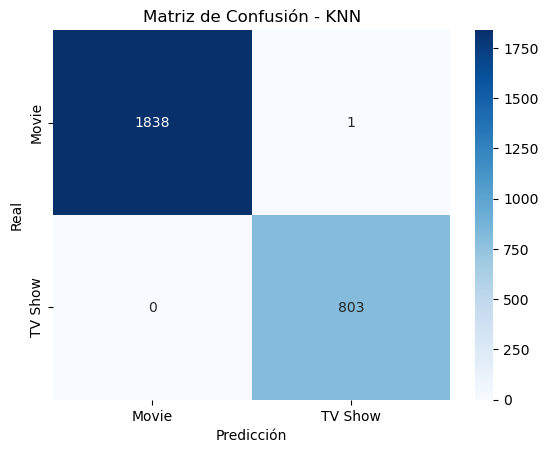

In [49]:
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Movie', 'TV Show'], yticklabels=['Movie', 'TV Show'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - KNN')
plt.show()